In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)

In [3]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


NAV Trend Analysis

Requirement:

Plot daily NAV for all 40 schemes 2022–2026
Highlight 2023 bull run and 2024 correction
Use Plotly
What are we analyzing?

NAV = fund value over time.

Need trend.

Example:

2023 → market bullish → NAV rises
2024 → correction → temporary fall

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.2
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    fillcolor="red",
    opacity=0.2
)

fig.show()

AUM Growth Bar Chart

Requirement:

Grouped bar chart by fund house
Highlight SBI ₹12.5 lakh crore dominance
Use Seaborn

AUM = Assets Under Management.

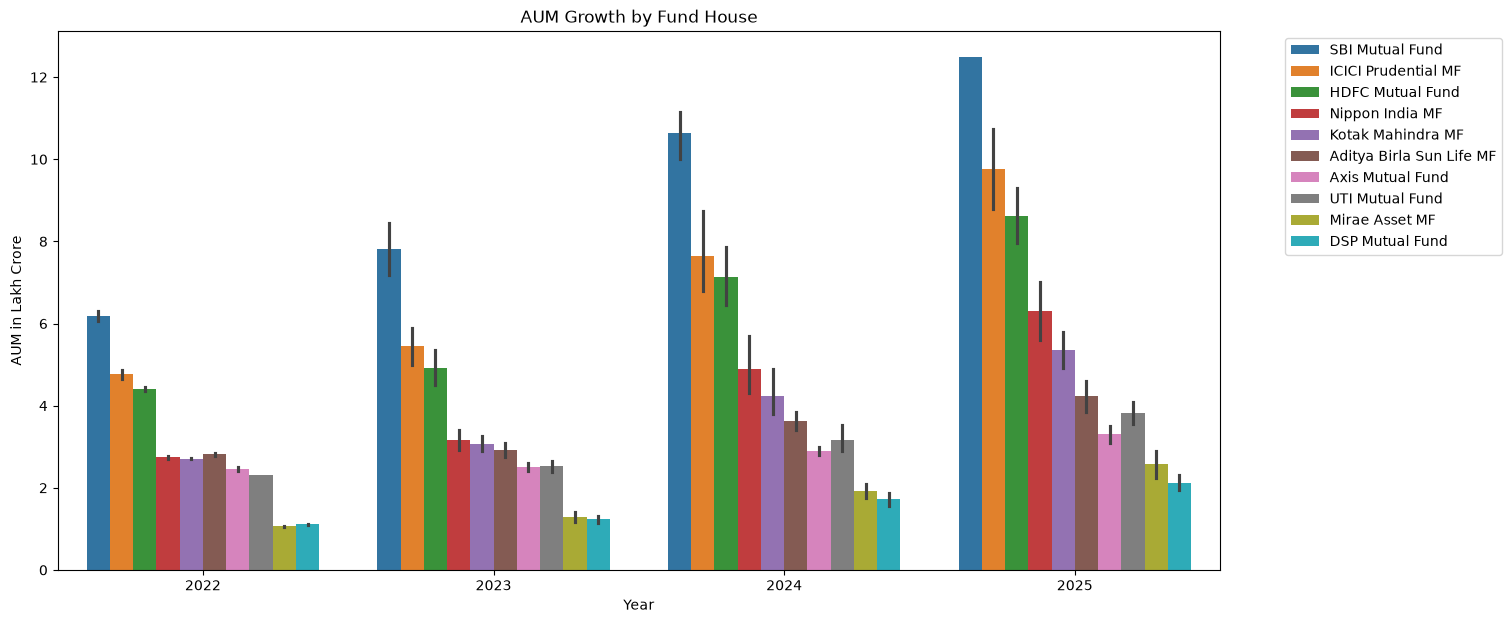

In [11]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.xlabel("Year")
plt.ylabel("AUM in Lakh Crore")

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.savefig("../charts/aum_growth.png")

plt.show()

SIP Inflow Time Series

Requirement:

Jan 2022 → Dec 2025
Mark ₹31,002 Cr in Dec 2025
Use Plotly

In [15]:
# check data first

print("Columns:")
print(sip.columns)

print("\nFirst 5 Rows:")
print(sip.head())


# convert month column into datetime

sip["month"] = pd.to_datetime(sip["month"])


# check highest SIP inflow

print("\nHighest SIP Inflow Value:")

print(sip["sip_inflow_crore"].max())


# find row where max exists

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print("\nHighest Value Row:")
print(max_row)


# create interactive line chart

fig = px.line(

    sip,

    x="month",

    y="sip_inflow_crore",

    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",

    markers=True
)


# annotate highest point December 2025

fig.add_annotation(

    x=max_row["month"],

    y=max_row["sip_inflow_crore"],

    text="All Time High ₹31,002 Cr",

    showarrow=True,

    arrowhead=2
)


# update labels

fig.update_layout(

    xaxis_title="Month",

    yaxis_title="SIP Inflow (Crore ₹)"
)


# save chart

fig.write_html("../charts/sip_trend.html")


print("\nChart saved successfully")

Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

First 5 Rows:
       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Highest SIP Inflow Value:
31002

Highest Value Row:
month                

Category Inflow Heatmap

Requirement:

Months → X axis
Fund categories → Y axis
Net inflow → color intensity
Use Seaborn

CATEGORY COLUMNS:
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


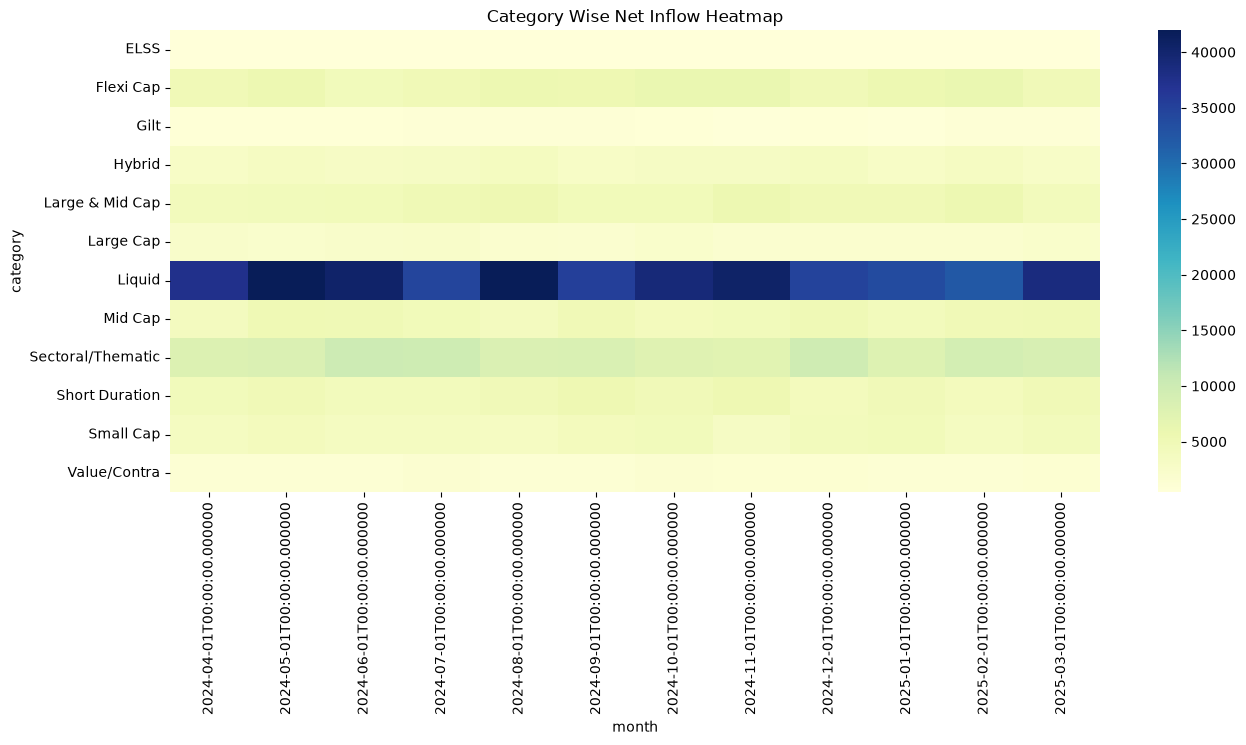

In [17]:
print("CATEGORY COLUMNS:")
print(category.columns)

# convert month column
category["month"] = pd.to_datetime(category["month"])

# pivot table
category_pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# heatmap
plt.figure(figsize=(15,6))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category Wise Net Inflow Heatmap")

plt.savefig("../charts/category_heatmap.png")

plt.show()

Investor Demographics

Need 3 charts.

Age group pie chart
SIP amount box plot
Gender split

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


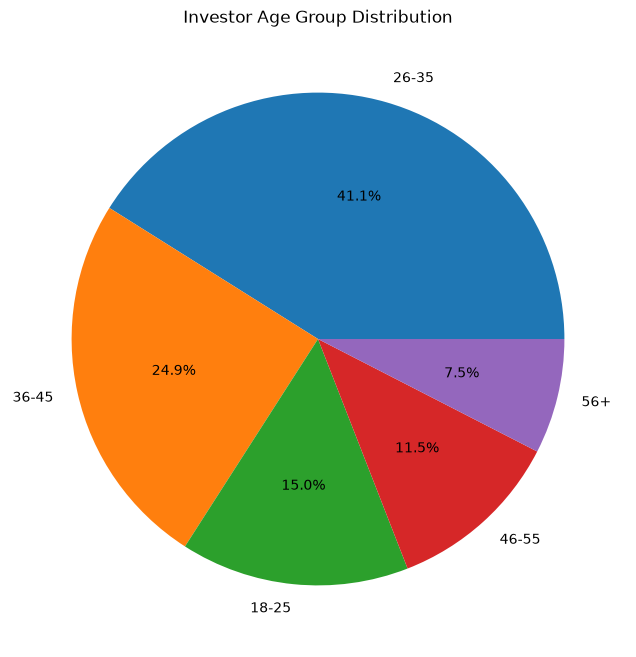

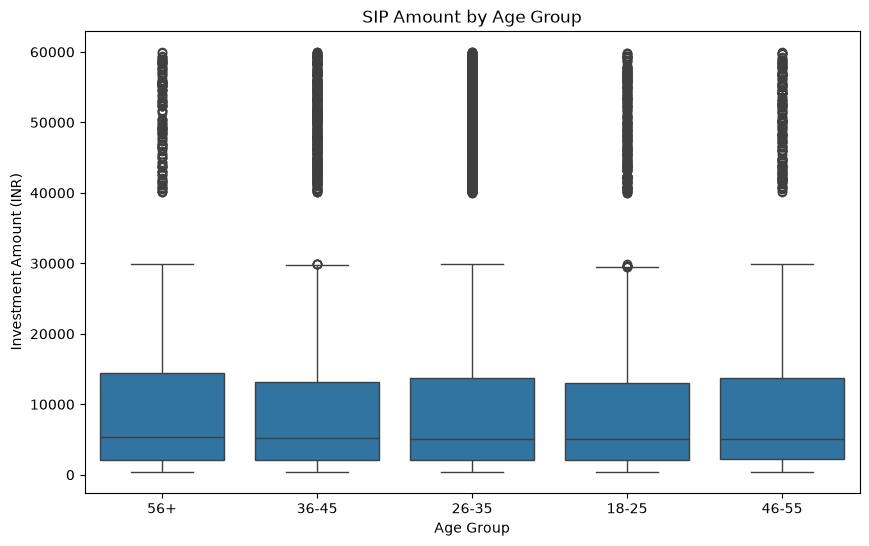

gender
Male      21809
Female    10969
Name: count, dtype: int64


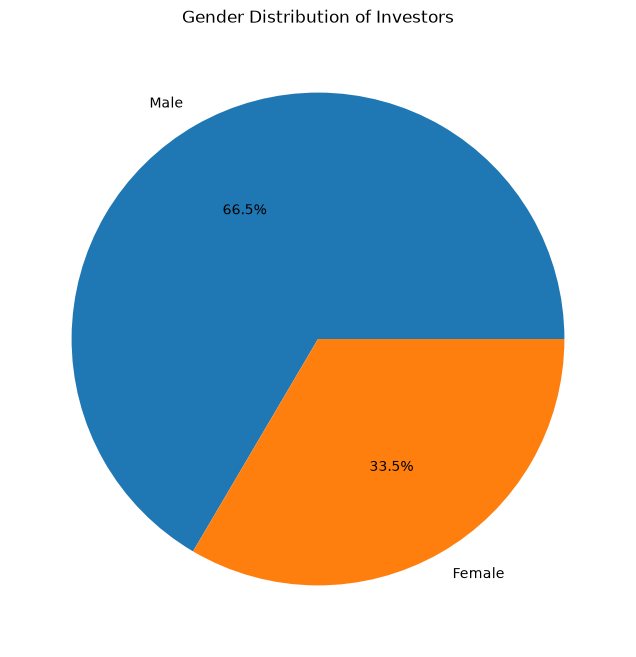

In [22]:
# ====================================
# TASK 5A : AGE GROUP DISTRIBUTION
# ====================================

print(investor["age_group"].value_counts())


# count age groups

age = investor["age_group"].value_counts()


# pie chart

plt.figure(figsize=(8,8))

plt.pie(

    age,

    labels=age.index,

    autopct="%1.1f%%"
)


plt.title("Investor Age Group Distribution")


plt.savefig("../charts/age_distribution.png")

# ====================================
# TASK 5B : SIP BOX PLOT
# ====================================

# only SIP transactions

sip_investors = investor[

    investor["transaction_type"] == "SIP"
]


plt.figure(figsize=(10,6))


sns.boxplot(

    data=sip_investors,

    x="age_group",

    y="amount_inr"
)


plt.title("SIP Amount by Age Group")


plt.xlabel("Age Group")


plt.ylabel("Investment Amount (INR)")


plt.savefig("../charts/sip_boxplot.png")


plt.show()
# ====================================
# TASK 5C : GENDER DISTRIBUTION
# ====================================


print(investor["gender"].value_counts())


# count genders

gender = investor["gender"].value_counts()


# pie chart

plt.figure(figsize=(8,8))


plt.pie(

    gender,

    labels=gender.index,

    autopct="%1.1f%%"
)


plt.title("Gender Distribution of Investors")


plt.savefig("../charts/gender_split.png")


plt.show()


Geographic Distribution 

Need:

1. SIP amount by state
2. T30 vs B30 city tier pie chart

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


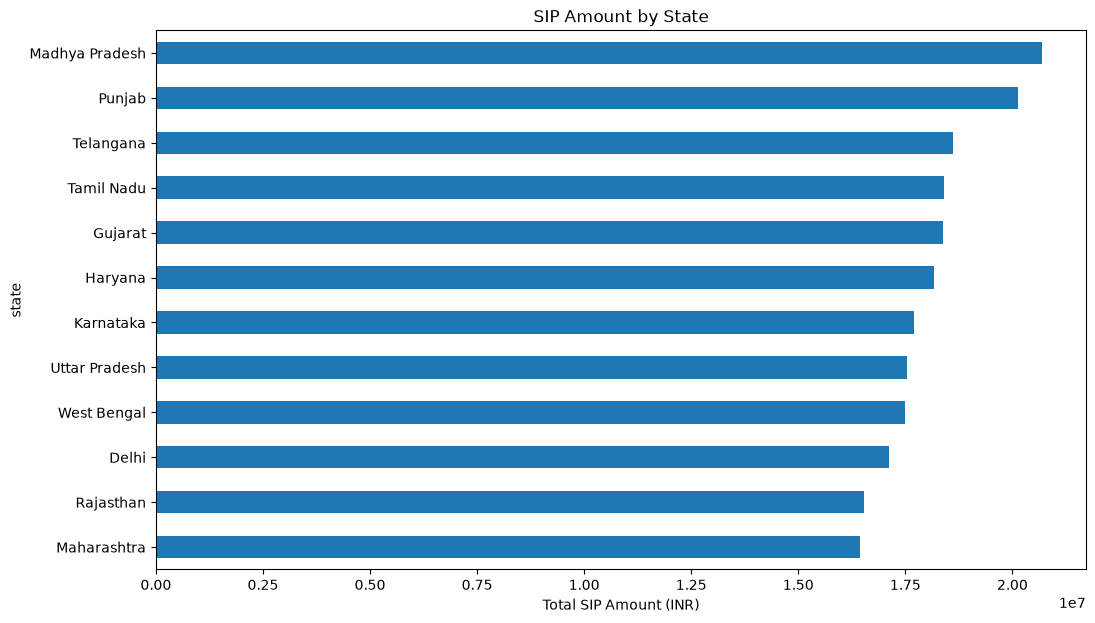

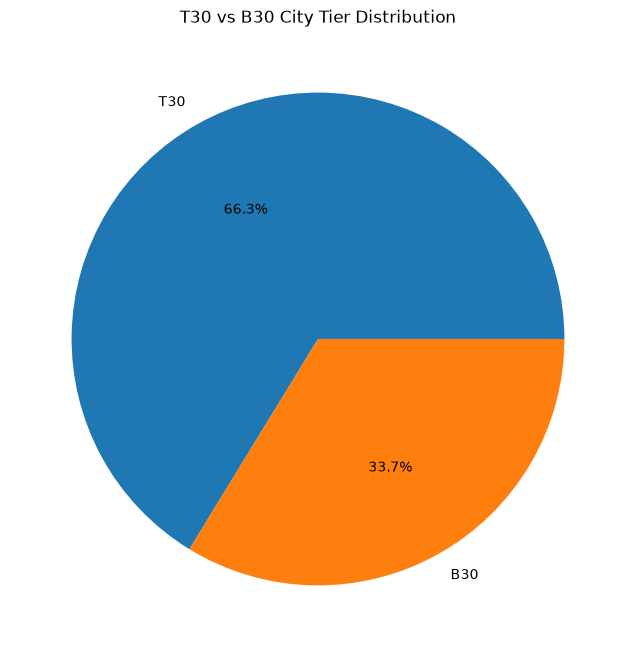

In [23]:
# ====================================
# TASK 6A : SIP AMOUNT BY STATE
# ====================================

# only SIP transactions

sip_state = investor[

    investor["transaction_type"] == "SIP"
]


# group by state

state = sip_state.groupby(

    "state"

)["amount_inr"].sum()


# horizontal bar

plt.figure(figsize=(12,7))


state.sort_values().plot(

    kind="barh"
)


plt.title("SIP Amount by State")


plt.xlabel("Total SIP Amount (INR)")


plt.savefig("../charts/state_distribution.png")

# ====================================
# TASK 6B : T30 vs B30 DISTRIBUTION
# ====================================


print(investor["city_tier"].value_counts())


# count city tiers

city = investor["city_tier"].value_counts()


plt.figure(figsize=(8,8))


plt.pie(

    city,

    labels=city.index,

    autopct="%1.1f%%"
)


plt.title("T30 vs B30 City Tier Distribution")


plt.savefig("../charts/t30_b30.png")


plt.show()



7

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


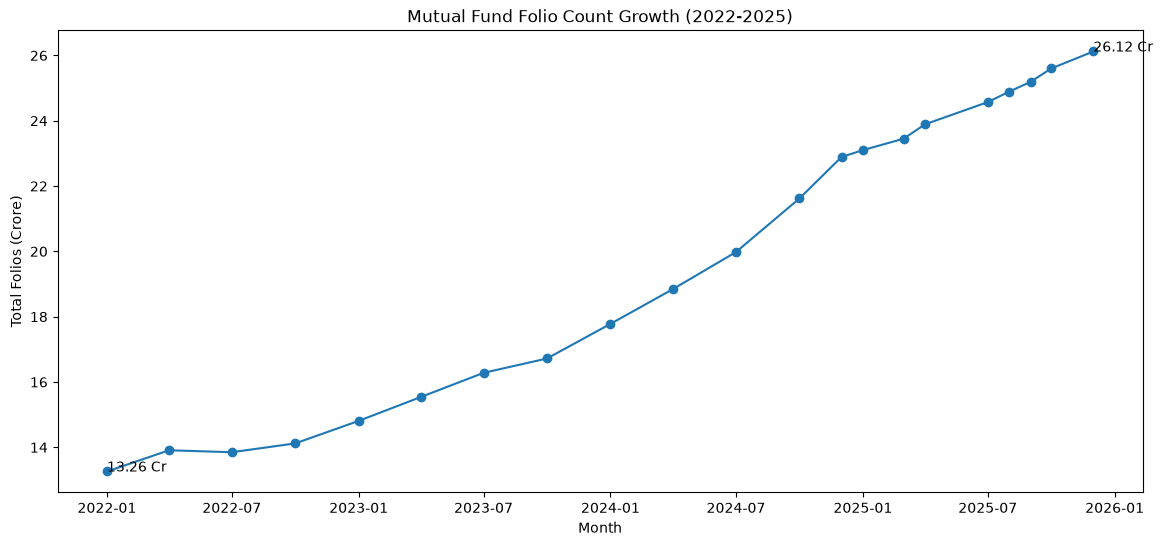

In [25]:
print(folio.columns)
print(folio.head())


# convert month column

folio["month"] = pd.to_datetime(folio["month"])


# create line chart

plt.figure(figsize=(14,6))


plt.plot(

    folio["month"],

    folio["total_folios_crore"],

    marker="o"
)


# annotate starting milestone

plt.annotate(

    "13.26 Cr",

    xy=(

        folio.iloc[0]["month"],

        folio.iloc[0]["total_folios_crore"]

    )
)


# annotate ending milestone

plt.annotate(

    "26.12 Cr",

    xy=(

        folio.iloc[-1]["month"],

        folio.iloc[-1]["total_folios_crore"]

    )
)


plt.title("Mutual Fund Folio Count Growth (2022-2025)")


plt.xlabel("Month")


plt.ylabel("Total Folios (Crore)")


plt.savefig("../charts/folio_growth.png")


plt.show()

NAV Return Correlation Matrix

Requirement:

Compute pairwise correlation of daily returns for 10 selected funds
Use Seaborn Heatmap
First understand

You have NAV data:

Fund A → NAV changes daily
Fund B → NAV changes daily

We calculate daily return:

Formula:

(today NAV - yesterday NAV) / yesterday NAV

Example:

Day1 = 100
Day2 = 110

Return = (110-100)/100 = 10%

Then compare funds.

If correlation =

1     → move together exactly
0     → no relation
-1    → opposite movement

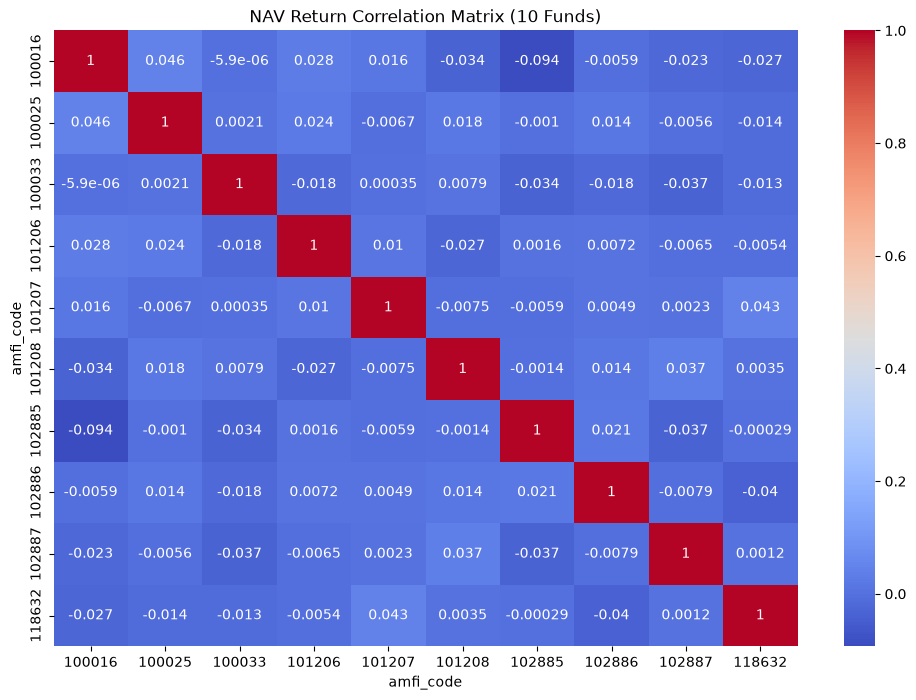

amfi_code    100016    100025    100033    101206    101207    101208  \
amfi_code                                                               
100016     1.000000  0.045567 -0.000006  0.027747  0.016053 -0.033773   
100025     0.045567  1.000000  0.002150  0.023769 -0.006710  0.018455   
100033    -0.000006  0.002150  1.000000 -0.018079  0.000351  0.007864   
101206     0.027747  0.023769 -0.018079  1.000000  0.010202 -0.027230   
101207     0.016053 -0.006710  0.000351  0.010202  1.000000 -0.007530   
101208    -0.033773  0.018455  0.007864 -0.027230 -0.007530  1.000000   
102885    -0.093533 -0.001038 -0.034228  0.001570 -0.005929 -0.001436   
102886    -0.005867  0.013754 -0.018166  0.007229  0.004860  0.014307   
102887    -0.023316 -0.005648 -0.036647 -0.006490  0.002304  0.036547   
118632    -0.026781 -0.014166 -0.013318 -0.005432  0.043384  0.003507   

amfi_code    102885    102886    102887    118632  
amfi_code                                          
100016    -0.093533

In [27]:
# sort values

nav = nav.sort_values(["amfi_code", "date"])


# calculate daily returns

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()


# choose first 10 funds

codes = nav["amfi_code"].unique()[:10]


# filter only 10 funds

small = nav[nav["amfi_code"].isin(codes)]


# create pivot table

nav_pivot = small.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)


# correlation matrix

corr = nav_pivot.corr()


# plot heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix (10 Funds)")

plt.savefig("../charts/correlation_matrix.png")

plt.show()


# print matrix

print(corr)

Sector Allocation Donut Chart

Requirement:

Aggregate sector weights from portfolio_holdings.csv
Create donut chart

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Sector Allocation:
sector
Aut

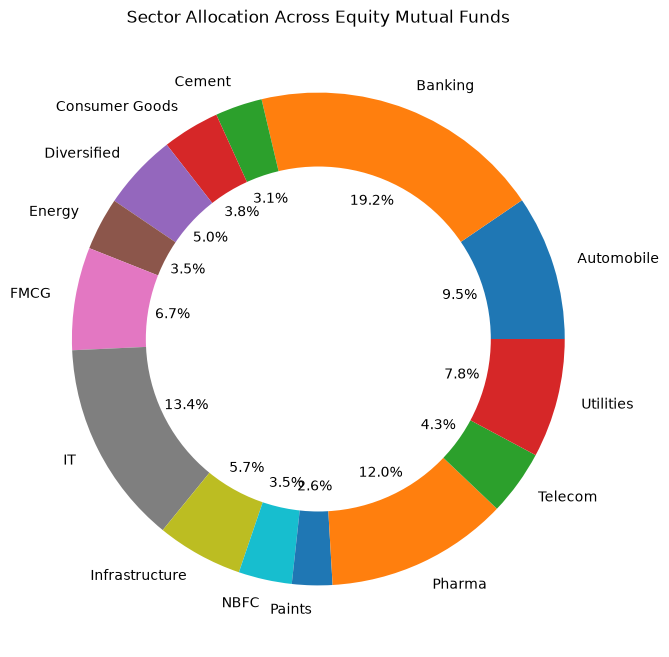

In [29]:
# check data

print(portfolio.columns)

print(portfolio.head())


# aggregate sector allocation

sector = portfolio.groupby(

    "sector"

)["weight_pct"].sum()


# print sector totals

print("\nSector Allocation:")

print(sector)


# create figure

plt.figure(figsize=(10,8))


# pie chart

plt.pie(

    sector,

    labels=sector.index,

    autopct="%1.1f%%"
)


# create donut hole

centre_circle = plt.Circle(

    (0,0),

    0.70,

    fc="white"
)


# add circle

fig = plt.gcf()

fig.gca().add_artist(

    centre_circle
)


# title

plt.title("Sector Allocation Across Equity Mutual Funds")


# save chart

plt.savefig("../charts/sector_donut.png")


# show chart

plt.show()

EXTRA CHART 13 — Transaction Type Distribution

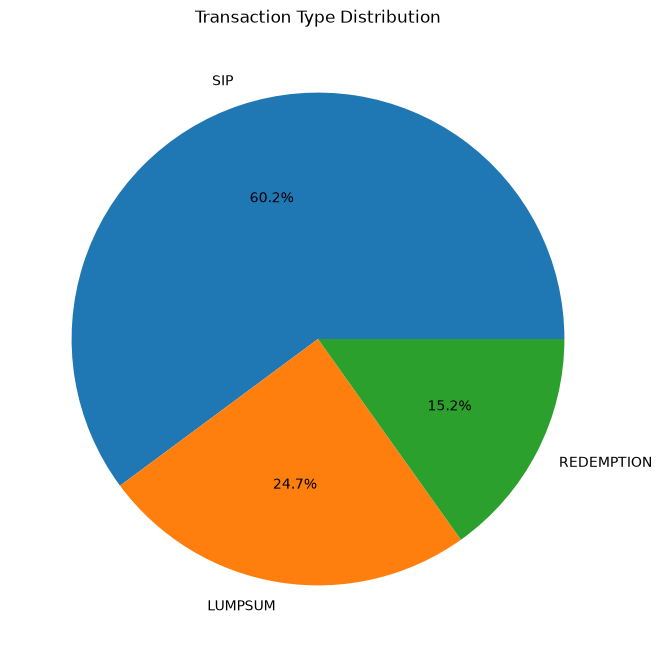

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64


In [33]:
# ==========================================
# EXTRA CHART 13 : TRANSACTION TYPE
# ==========================================

transaction = investor["transaction_type"].value_counts()


plt.figure(figsize=(8,8))


transaction.plot(

    kind="pie",

    autopct="%1.1f%%"
)


plt.title("Transaction Type Distribution")


plt.savefig("../charts/transaction_type.png")


plt.show()


print(transaction)

EXTRA CHART 14 — Payment Mode Distribution

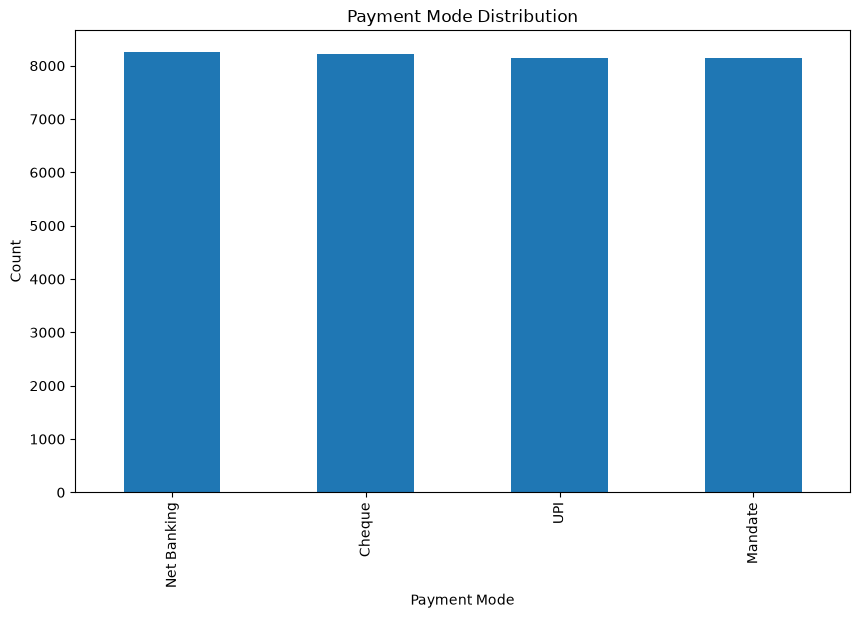

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64


In [34]:
# ==========================================
# EXTRA CHART 14 : PAYMENT MODE
# ==========================================

payment = investor["payment_mode"].value_counts()


plt.figure(figsize=(10,6))


payment.plot(

    kind="bar"
)


plt.title("Payment Mode Distribution")


plt.xlabel("Payment Mode")


plt.ylabel("Count")


plt.savefig("../charts/payment_mode.png")


plt.show()


print(payment)

EXTRA CHART 15 — Income Distribution

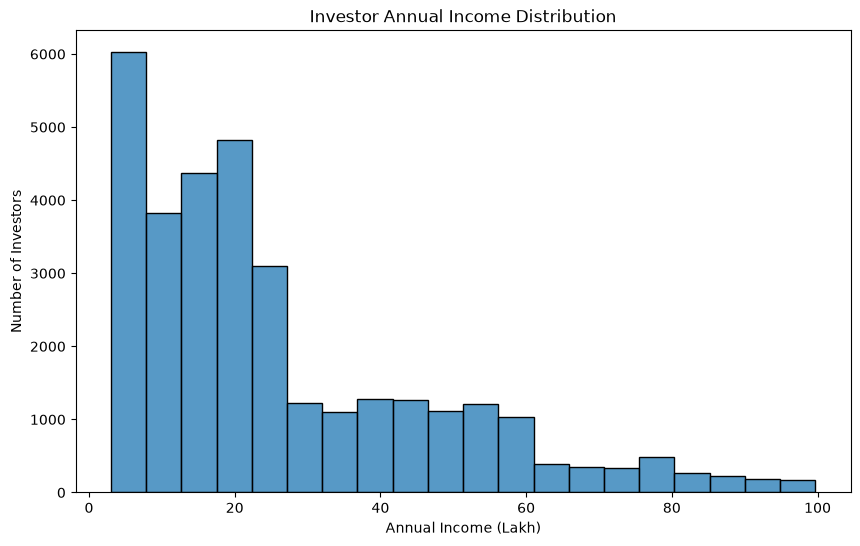

In [35]:
# ==========================================
# EXTRA CHART 15 : INCOME DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))


sns.histplot(

    investor["annual_income_lakh"],

    bins=20
)


plt.title("Investor Annual Income Distribution")


plt.xlabel("Annual Income (Lakh)")


plt.ylabel("Number of Investors")


plt.savefig("../charts/income_distribution.png")


plt.show()

10 Markdown Insight Cells

INSIGHT 1 - Daily NAV values showed strong upward growth during the 2023 bull market across all mutual fund schemes.

INSIGHT 2 - SBI Mutual Fund consistently maintained the highest Assets Under Management, showing strong market leadership.

INSIGHT 3 - Monthly SIP inflows steadily increased and reached an all-time high of ₹31,002 crore in December 2025.

INSIGHT 4 - Equity mutual fund categories attracted the highest net inflows across most months compared to other categories.

INSIGHT 5 - Investors aged 26–35 contributed the largest share of mutual fund participation in the investor base.

INSIGHT 6 - SIP investment amounts varied across age groups, with middle-aged investors investing higher average amounts.

INSIGHT 7 - Tier-1 cities (T30) contributed the majority of SIP investments compared to smaller B30 cities.

INSIGHT 8 - Mutual fund folio count increased significantly from 13.26 crore in 2022 to 26.12 crore in 2025.

INSIGHT 9 - Several equity mutual funds showed strong positive correlation in daily NAV returns due to similar market movement.

INSIGHT 10 - Banking, Technology and Pharma sectors dominated portfolio allocation across equity mutual funds.